## Imports necesery for proper execution of the code.

In [1]:
from src.data_analysis_pack import join_datasets, load_and_preprocess_population, load_and_preprocess_alcohol, \
    load_and_preprocess_fire_events, calculate_statistics, calculate_correlation, plot_correlation, \
    save_statistics_as_csv, save_statistics_as_excel
import pandas as pd

## File parameters
(Don't know if I remember correctly, but I think you let us skip using argparse if we chose to use the notebook instead of script)
There are a few more parameters for some of the functions, in this case they use the basic values. To see them go to source code.

In [2]:
# loading parameters
alco_data_path = "data/alcohol_data/raport_zezwolen_alkoholowych_czynych_na_dzien_4_lutego_2025_r.csv"
alco_dictionary_path = "data/alcohol_data/zipcodes_dict.csv"
fire_data_path = "data/fire_events_data/1.csv"
population_data_path = "data/population_data/tabela05.xls"
population_data_sheet_name = "Tabl. 5"
rows_to_skip = [0, 1, 2, 3, 4, 6, 7, 8]

In [3]:
# saving parameters
result_csv_path = "data/result_data/result.csv"
result_excel_path = "data/result_data/result.xlsx"
result_sheet_name = "fire_and_alcohol_statistics"

## Data loading and preprocessing
Due to incomplete information about zipcodes in the zipcode-powiat dictionary we lost 7.5% of the data about alcohol selling companies. It's not a number so big we should be worried about the results. Additionally, due to 10 pairs of powiats having the exact same name 20 of powiats got removed from data. It's 5% of all powiats.

After this process we are left with one big dataset with powiats as untis, containing data about population, fire events and alcohol selling companies.

In [4]:
%%time
data_alco = load_and_preprocess_alcohol(alco_data_path, alco_dictionary_path)
data_fire = load_and_preprocess_fire_events(fire_data_path)
data_population = load_and_preprocess_population(population_data_path, population_data_sheet_name, rows_to_skip)
final_data = join_datasets(data_alco, data_fire, data_population)

final_data.head()

CPU times: total: 62.5 ms
Wall time: 119 ms


,num,m,f,procentage_of_m,Num of alc,RAZEM Pożar (P),RAZEM Miejscowe zagrożenie (MZ),RAZEM Alarm fałszywy (AF)
Powiat,,,,,,,,
bolesławiecki,87255,42244,45011,48.414418,0.0,468.0,1246.0,142.0
dzierżoniowski,93863,44496,49367,47.405261,2.0,302.0,1002.0,93.0
głogowski,84387,40823,43564,48.375935,0.0,303.0,620.0,156.0
górowski,32054,15861,16193,49.482124,0.0,151.0,503.0,19.0
jaworski,46822,22913,23909,48.936397,0.0,193.0,1093.0,84.0


## Population, fire and alcohol statistics

In [5]:
%%time
result_data = calculate_statistics(final_data)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

save_statistics_as_csv(result_data, result_csv_path)
save_statistics_as_excel(result_data, result_excel_path, result_sheet_name)
result_data

CPU times: total: 297 ms
Wall time: 359 ms


,min,max,mean,median,std,variance
num,18434.000,1863845.00,99277.011,73047.000,126965.561,1.612025e+10
m,9170.000,861340.00,47926.081,35656.500,59038.078,3.485495e+09
f,9264.000,1002505.00,51350.931,37001.500,67956.640,4.618105e+09
procentage_of_m,45.665,51.17,48.736,48.977,0.957,9.160000e-01
Num of alc,0.000,63.00,1.006,0.000,3.646,1.329200e+01
RAZEM Pożar (P),0.000,4252.00,272.772,209.000,290.707,8.451039e+04
RAZEM Miejscowe zagrożenie (MZ),0.000,13139.00,1029.858,772.000,1015.162,1.030553e+06
RAZEM Alarm fałszywy (AF),0.000,5456.00,142.886,78.000,348.111,1.211813e+05


## Correlations
In this sction we test 4 hypotesis about correlation in the population.

`1.` Correlation between the number of people living in an area (powiat) and the number of fire events:

In [6]:
%%time
cor, res, p = calculate_correlation(final_data, "num", "RAZEM Pożar (P)")
print(f"Correlation: {cor}. {res}")

Correlation: 0.947. The result is statistically significant. p-value < 0.001.
CPU times: total: 0 ns
Wall time: 4.05 ms


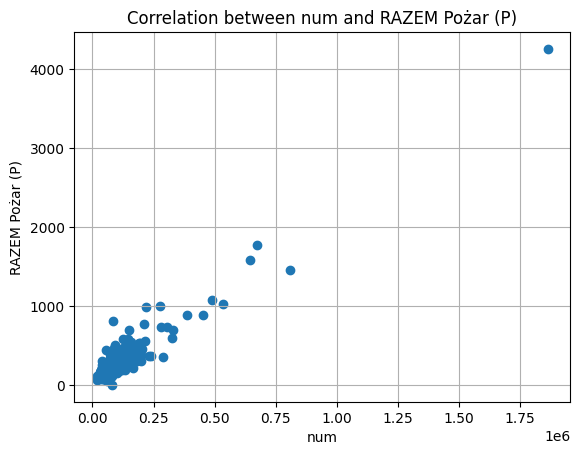

In [7]:
plot_correlation(final_data, "num", "RAZEM Pożar (P)")

`2.` Correlation between the number of people living in an area (powiat) and the number of alcohol selling companies:

In [8]:
cor, res, p = calculate_correlation(final_data, "num", "Num of alc")
print(f"Correlation: {cor}. {res}")

Correlation: 0.882. The result is statistically significant. p-value < 0.001.


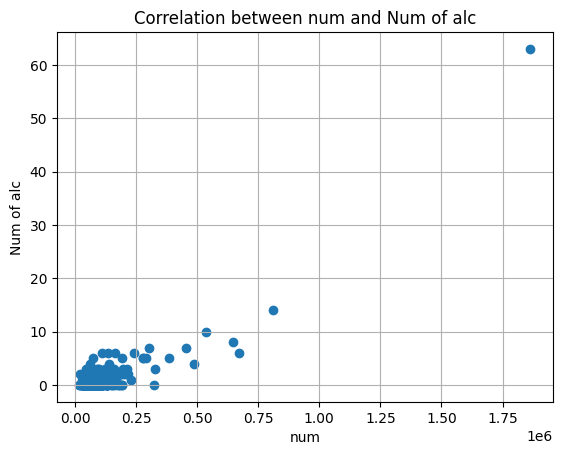

In [9]:
plot_correlation(final_data, "num", "Num of alc")

`3.` Correlation between the number of fire events in an area (powiat) and the number of alcohol selling companies:

In [10]:
cor, res, p = calculate_correlation(final_data, "RAZEM Pożar (P)", "Num of alc")
print(f"Correlation: {cor}. {res}")

Correlation: 0.841. The result is statistically significant. p-value < 0.001.


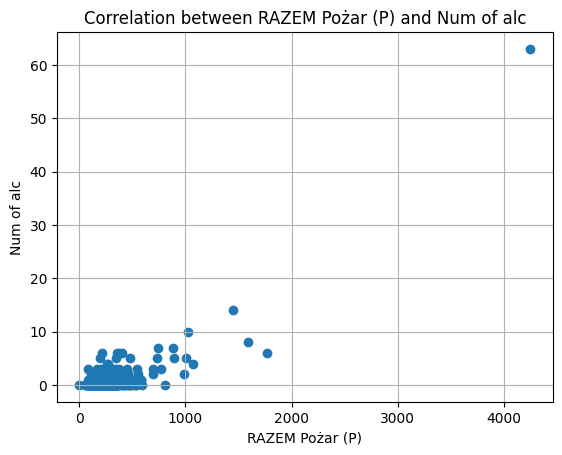

In [11]:
plot_correlation(final_data, "RAZEM Pożar (P)", "Num of alc")

`4.` Correlation between the procentage of males in an area (powiat) and the number of false alarms in the fire stations:

In [12]:
cor, res, p = calculate_correlation(final_data, "procentage_of_m", "RAZEM Alarm fałszywy (AF)")
print(f"Correlation: {cor}. {res}")

Correlation: -0.395. The result is statistically significant. p-value < 0.001.


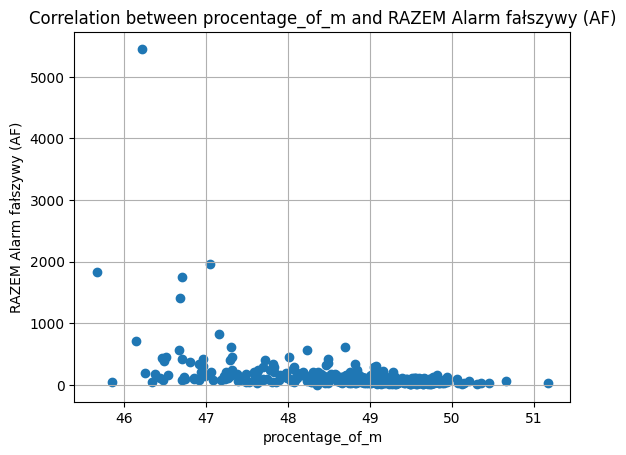

In [13]:
plot_correlation(final_data,  "procentage_of_m", "RAZEM Alarm fałszywy (AF)")

## Profiling
I tried profiling the notebook with snakeviz, but since most functions used in the package are based on pandas the result was nonsensical. I decided to use %%time, but it doesn't give much information, so I transformed this notebook into a script and used the built-in python profiler on that script.